# Лабораторная работа: Линейная регрессия

**Цель работы:** изучение основ линейной регрессии, построение простейших моделей регрессии (обычная линейная, Lasso, Ridge), обучение на реальных метеорологических данных, оценка качества моделей, анализ мультиколлинеарности и снижение размерности методом главных компонент (PCA).

---

## 1. Введение

Линейная регрессия — один из фундаментальных методов машинного обучения и статистики. Она позволяет моделировать зависимость непрерывной целевой переменной от одного или нескольких признаков в предположении линейной связи.

В данной работе мы:
1. Загрузим и исследуем реальный датасет метеорологических наблюдений станции Варшава-Окенце (Польша).
2. Проведём первичный анализ данных, визуализацию распределений и корреляций.
3. Выполним предобработку: обработку пропусков, создание признаков из даты, стандартизацию.
4. Построим модели линейной регрессии, Lasso и Ridge-регрессии.
5. Оценим качество с помощью метрик RMSE, R² и MAPE, а также кросс-валидации.
6. Проанализируем остатки на гомоскедастичность.
7. Исследуем мультиколлинеарность (VIF) и устраним её с помощью PCA.
8. Сравним качество моделей до и после PCA.

Целевая переменная — **среднесуточная температура воздуха (TAVG)**. Признаки — календарные характеристики даты, количество осадков и высота снежного покрова.

## 2. Описание датасета

Датасет содержит ежедневные метеорологические наблюдения станции **Warsaw Okęcie (PLM00012375)** за период с **1 января 1993 года по 31 декабря 2022 года** (30 лет, 10 954 дня).

**Исходные столбцы:**
- `STATION`, `NAME` — идентификатор и название станции (константы)
- `LATITUDE`, `LONGITUDE`, `ELEVATION` — географические координаты и высота (константы: 52.166°, 20.967°, 110.3 м)
- `DATE` — дата наблюдения
- `PRCP` — суточное количество осадков (мм)
- `SNWD` — высота снежного покрова (мм)
- `TAVG` — средняя суточная температура (°C) — **целевая переменная**
- `TMAX` — максимальная суточная температура (°C)

Данные получены из открытых источников (NOAA / GHCN). Аналогичные наборы часто встречаются на Kaggle и в репозиториях климатических данных.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

### 2.1. Загрузка данных

In [ ]:
df_raw = pd.read_csv('/home/workdir/attachments/warsaw-selected-columns.csv')
print('Размер исходного датасета:', df_raw.shape)
print('\nСтолбцы:', df_raw.columns.tolist())
print('\nТипы данных:')
print(df_raw.dtypes)
print('\nПервые 8 строк:')
display(df_raw.head(8))
print('\nОписательная статистика числовых столбцов:')
display(df_raw.describe().round(2))

**Пояснение.** Датасет содержит 10 954 наблюдения (по одному на каждый день за 30 лет). Столбцы `STATION`, `NAME`, `LATITUDE`, `LONGITUDE`, `ELEVATION` — константы, они не несут информации для моделирования и будут удалены. Целевая переменная `TAVG` заполнена полностью (0 пропусков). В `PRCP` и особенно в `SNWD` много пропусков — это типично для метеоданных: отсутствие записи часто означает отсутствие осадков/снега.

In [ ]:
print('Пропущенные значения:')
print(df_raw.isnull().sum())
print('\nДиапазон дат:', df_raw['DATE'].min(), '—', df_raw['DATE'].max())
print('Уникальных дат:', df_raw['DATE'].nunique())

## 3. Подготовка данных

### 3.1. Создание признаков из даты и обработка пропусков

Из столбца `DATE` извлечём:
- `year` — год (для учёта возможного тренда потепления)
- `month` — месяц (1–12)
- `day_of_year` — день года (1–366)
- `sin_doy`, `cos_doy` — синус и косинус дня года (для гладкого учёта сезонности)

Пропуски в `PRCP` и `SNWD` заменим нулями (логика: нет записи = нет осадков/снега). Столбец `TMAX` не используем как признак, чтобы избежать утечки информации (он сильно коррелирует с `TAVG`).

In [ ]:
df = df_raw.copy()
df['DATE'] = pd.to_datetime(df['DATE'])

# Календарные признаки
df['year'] = df['DATE'].dt.year
df['month'] = df['DATE'].dt.month
df['day_of_year'] = df['DATE'].dt.dayofyear
df['sin_doy'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
df['cos_doy'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)

# Обработка пропусков
df['PRCP'] = df['PRCP'].fillna(0)
df['SNWD'] = df['SNWD'].fillna(0)

# Целевая переменная и признаки
target = 'TAVG'
feature_cols = ['year', 'month', 'day_of_year', 'sin_doy', 'cos_doy', 'PRCP', 'SNWD']

X = df[feature_cols].copy()
y = df[target].copy()

print('Признаки:', feature_cols)
print('Размер X:', X.shape)
print('Пропуски в X после обработки:')
print(X.isnull().sum())
print('\nПропуски в y:', y.isnull().sum())
print('\nПервые строки признаков:')
display(X.head())

**Пояснение.** Мы создали 7 признаков. Сезонные `sin_doy` и `cos_doy` позволяют модели улавливать годовой цикл температуры без резких скачков на границе года. `year` может уловить долгосрочный тренд. `PRCP` и `SNWD` добавляют информацию о погодных условиях, влияющих на температуру.

### 3.2. Визуализация распределений признаков и целевой переменной

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, col in enumerate(feature_cols + [target]):
    if col in ['month']:
        sns.countplot(x=df[col], ax=axes[i], color='steelblue')
    else:
        sns.histplot(df[col], kde=True, ax=axes[i], bins=40)
    axes[i].set_title(col)

plt.tight_layout()
plt.suptitle('Распределения признаков и целевой переменной TAVG', y=1.02, fontsize=14)
plt.show()

**Пояснение графиков.**
- `TAVG` имеет примерно симметричное распределение с центром около 9 °C (типично для умеренного климата Варшавы).
- `year` — равномерное распределение по годам.
- `month` и `day_of_year` — почти равномерны (каждый месяц/день года представлен примерно одинаково).
- `sin_doy` и `cos_doy` — характерные «волны» (проекции годового цикла).
- `PRCP` и `SNWD` сильно скошены вправо: большинство дней без осадков и без снега.

**Рисунок 1.** Распределения признаков и целевой переменной TAVG. Видна симметрия TAVG, скошенность PRCP/SNWD и равномерность календарных признаков.

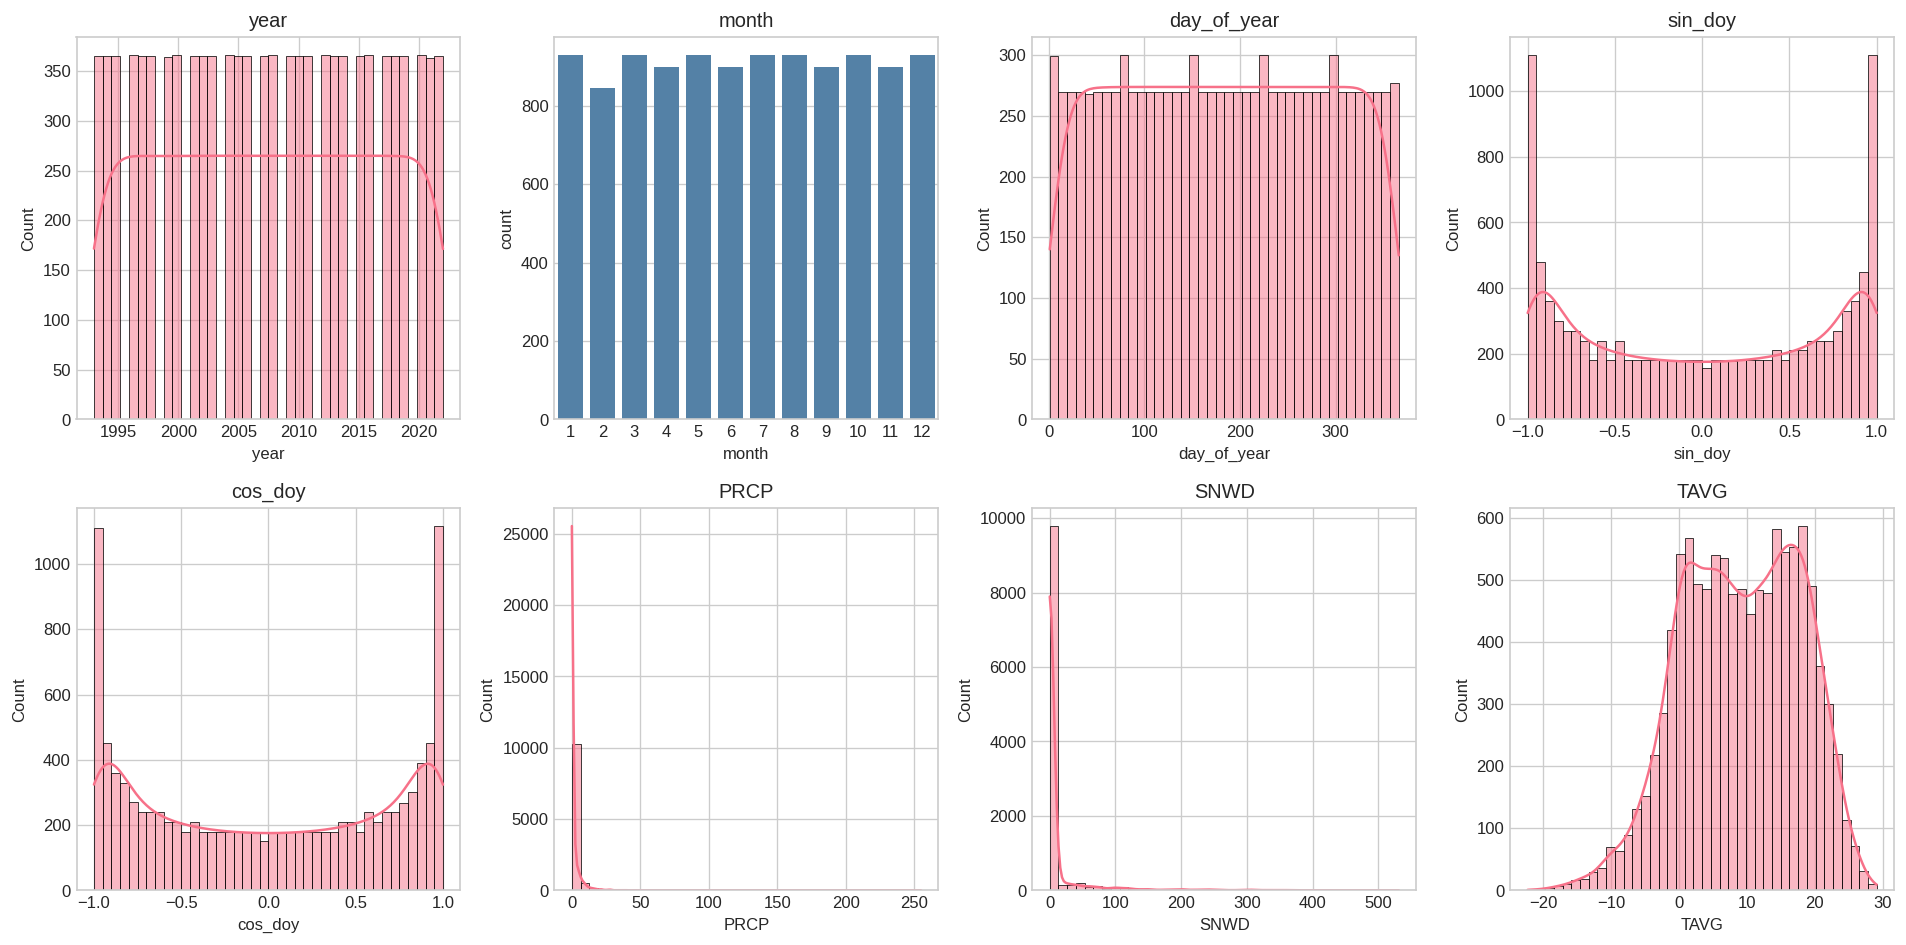


In [ ]:
# Временной ряд средней температуры
plt.figure(figsize=(14, 4))
plt.plot(df['DATE'], df['TAVG'], alpha=0.4, linewidth=0.5)
df_yearly = df.groupby('year')['TAVG'].mean()
plt.plot(pd.to_datetime(df_yearly.index.astype(str) + '-07-01'), df_yearly.values, 
         color='red', linewidth=2, label='Среднегодовая TAVG')
plt.xlabel('Дата')
plt.ylabel('TAVG, °C')
plt.title('Временной ряд среднесуточной температуры (Варшава-Окенце, 1993–2022)')
plt.legend()
plt.tight_layout()
plt.show()

**Пояснение.** Хорошо виден годовой цикл (зима–лето). Красная линия — среднегодовые температуры; заметен слабый положительный тренд (потепление), что делает признак `year` потенциально полезным.

**Рисунок 2.** Временной ряд среднесуточной температуры (1993–2022). Синяя линия — ежедневные значения, красная — среднегодовая TAVG (слабый тренд потепления).

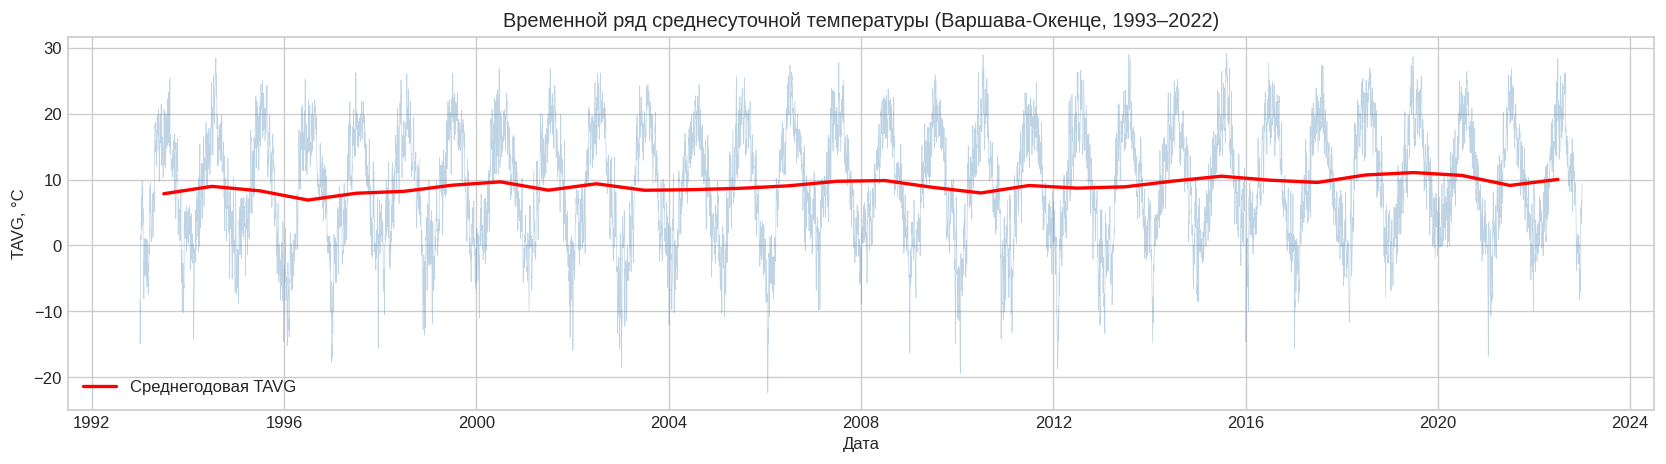


### 3.3. Разделение на обучающую и тестовую выборки

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Размер обучающей выборки: {X_train.shape}')
print(f'Размер тестовой выборки:  {X_test.shape}')
print(f'Доля теста: {len(y_test)/len(y):.1%}')

**Пояснение.** Использовано случайное разбиение 80/20 с фиксированным `random_state` для воспроизводимости. Для временных рядов иногда применяют временное разбиение (train — прошлые годы, test — последние), но для лабораторной работы по классической регрессии случайное разбиение допустимо и позволяет корректно сравнивать модели.

### 3.3.1. Нормализация (стандартизация) признаков

**Рекомендация:** если признаки сильно отличаются по масштабу, обязательно проведите нормализацию.

В нашем случае:
- `year` ~ 1993–2022
- `day_of_year` ~ 1–366
- `PRCP` ~ 0–255 мм
- `sin_doy`, `cos_doy` ∈ [−1, 1]

Масштабы различаются на порядки. Для **обычной линейной регрессии** стандартизация не обязательна (коэффициенты просто пересчитаются), но она:
1. Улучшает численную устойчивость.
2. Делает коэффициенты сопоставимыми.
3. **Обязательна** перед Lasso/Ridge (регуляризация чувствительна к масштабу) и перед PCA.

Используем `StandardScaler` (среднее = 0, стандартное отклонение = 1).

In [ ]:
# Стандартизация признаков (рекомендация по выполнению работы)
scaler_main = StandardScaler()
X_train_scaled_main = scaler_main.fit_transform(X_train)
X_test_scaled_main = scaler_main.transform(X_test)

# Преобразуем обратно в DataFrame для удобства
X_train_s = pd.DataFrame(X_train_scaled_main, columns=feature_cols, index=X_train.index)
X_test_s = pd.DataFrame(X_test_scaled_main, columns=feature_cols, index=X_test.index)

print('Средние после стандартизации (должны быть ≈ 0):')
print(X_train_s.mean().round(6))
print('\nСтд. отклонения после стандартизации (должны быть ≈ 1):')
print(X_train_s.std().round(6))

**Пояснение.** После стандартизации все признаки приведены к единому масштабу. Далее модели Lasso и Ridge будем обучать именно на стандартизованных данных. Обычную линейную регрессию покажем и на исходных, и на стандартизованных признаках (результаты почти совпадут).

### 3.4. Матрица корреляций

In [ ]:
df_corr = pd.concat([X, y], axis=1)
plt.figure(figsize=(10, 8))
corr = df_corr.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Матрица корреляций признаков и целевой переменной')
plt.tight_layout()
plt.show()

**Выводы по корреляциям.**
- `sin_doy` и `cos_doy` сильно коррелируют с `TAVG` (сезонность — главный фактор).
- `month` и `day_of_year` также связаны с температурой, но линейная корреляция слабее из-за нелинейности годового цикла.
- `SNWD` имеет отрицательную корреляцию с `TAVG` (снег бывает в холодные дни).
- `PRCP` почти не коррелирует с температурой линейно.
- Между `month`, `day_of_year`, `sin_doy`, `cos_doy` есть заметные корреляции — это источник мультиколлинеарности.

**Рисунок 3.** Матрица корреляций. Наиболее сильная связь TAVG с cos_doy и sin_doy; month и day_of_year коррелируют между собой.

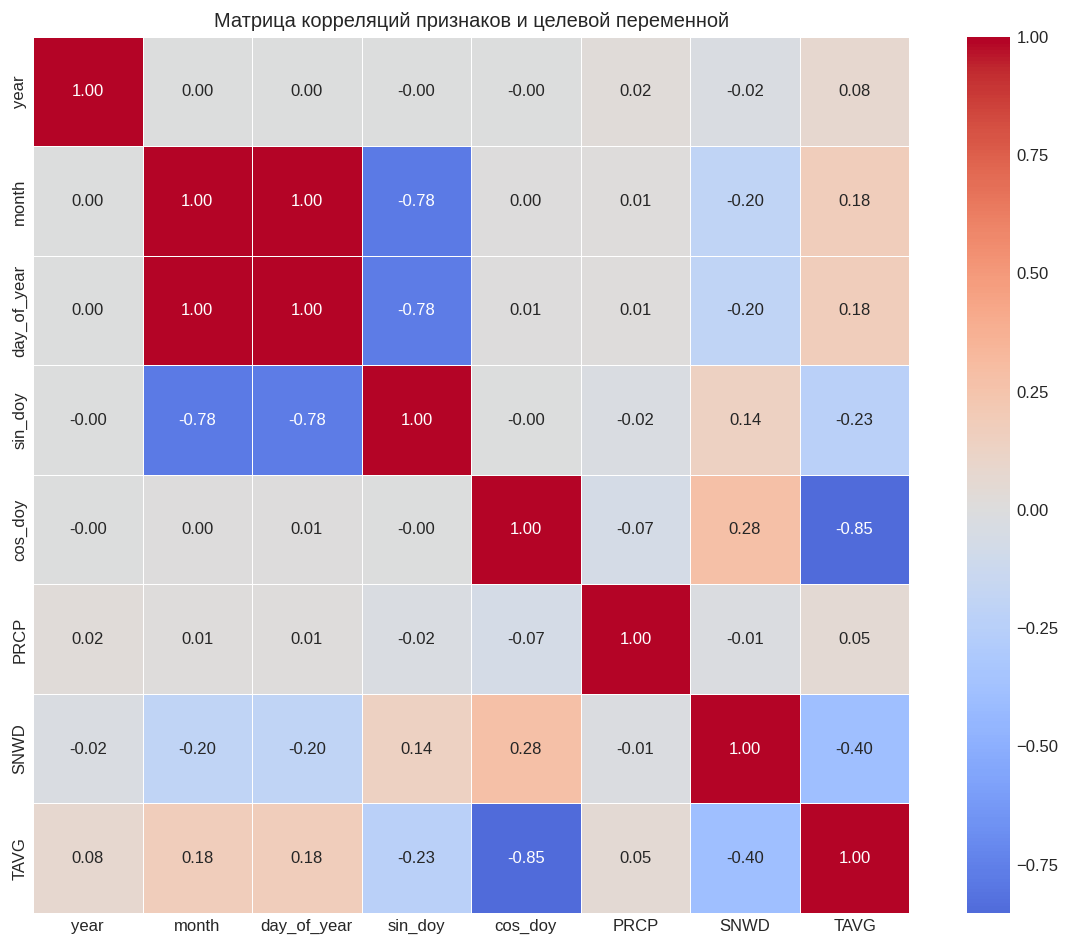


### 3.4.1. Визуальная проверка зависимости целевой переменной от признаков

**Рекомендация:** важно проверить зависимость целевого признака от независимых переменных (визуально или через корреляционный анализ).

Ниже — диаграммы рассеяния `TAVG` vs каждый признак. По ним можно увидеть:
- наличие/отсутствие линейной связи;
- нелинейность (например, сезонность);
- выбросы.

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, col in enumerate(feature_cols):
    axes[i].scatter(X[col], y, alpha=0.15, s=5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('TAVG')
    axes[i].set_title(f'TAVG vs {col}')

# последний subplot — пустой или бонус
axes[-1].axis('off')
plt.tight_layout()
plt.suptitle('Диаграммы рассеяния: зависимость TAVG от признаков', y=1.02, fontsize=13)
plt.show()

**Выводы по диаграммам рассеяния.**
- `sin_doy` и `cos_doy` показывают чёткую (почти синусоидальную) связь с температурой — сезонность.
- `month` и `day_of_year` дают «волнообразную» зависимость (нелинейную), поэтому линейная корреляция слабее.
- `SNWD` — при высоких значениях температура, как правило, низкая (отрицательная связь).
- `PRCP` — почти нет видимой линейной зависимости.
- `year` — очень слабый положительный тренд (потепление).

Эти наблюдения подтверждают корреляционный анализ и объясняют, почему сезонные признаки вносят основной вклад в R².

**Рисунок 4.** Диаграммы рассеяния TAVG vs признаки. Чёткая сезонная зависимость у sin_doy/cos_doy; отрицательная связь с SNWD.

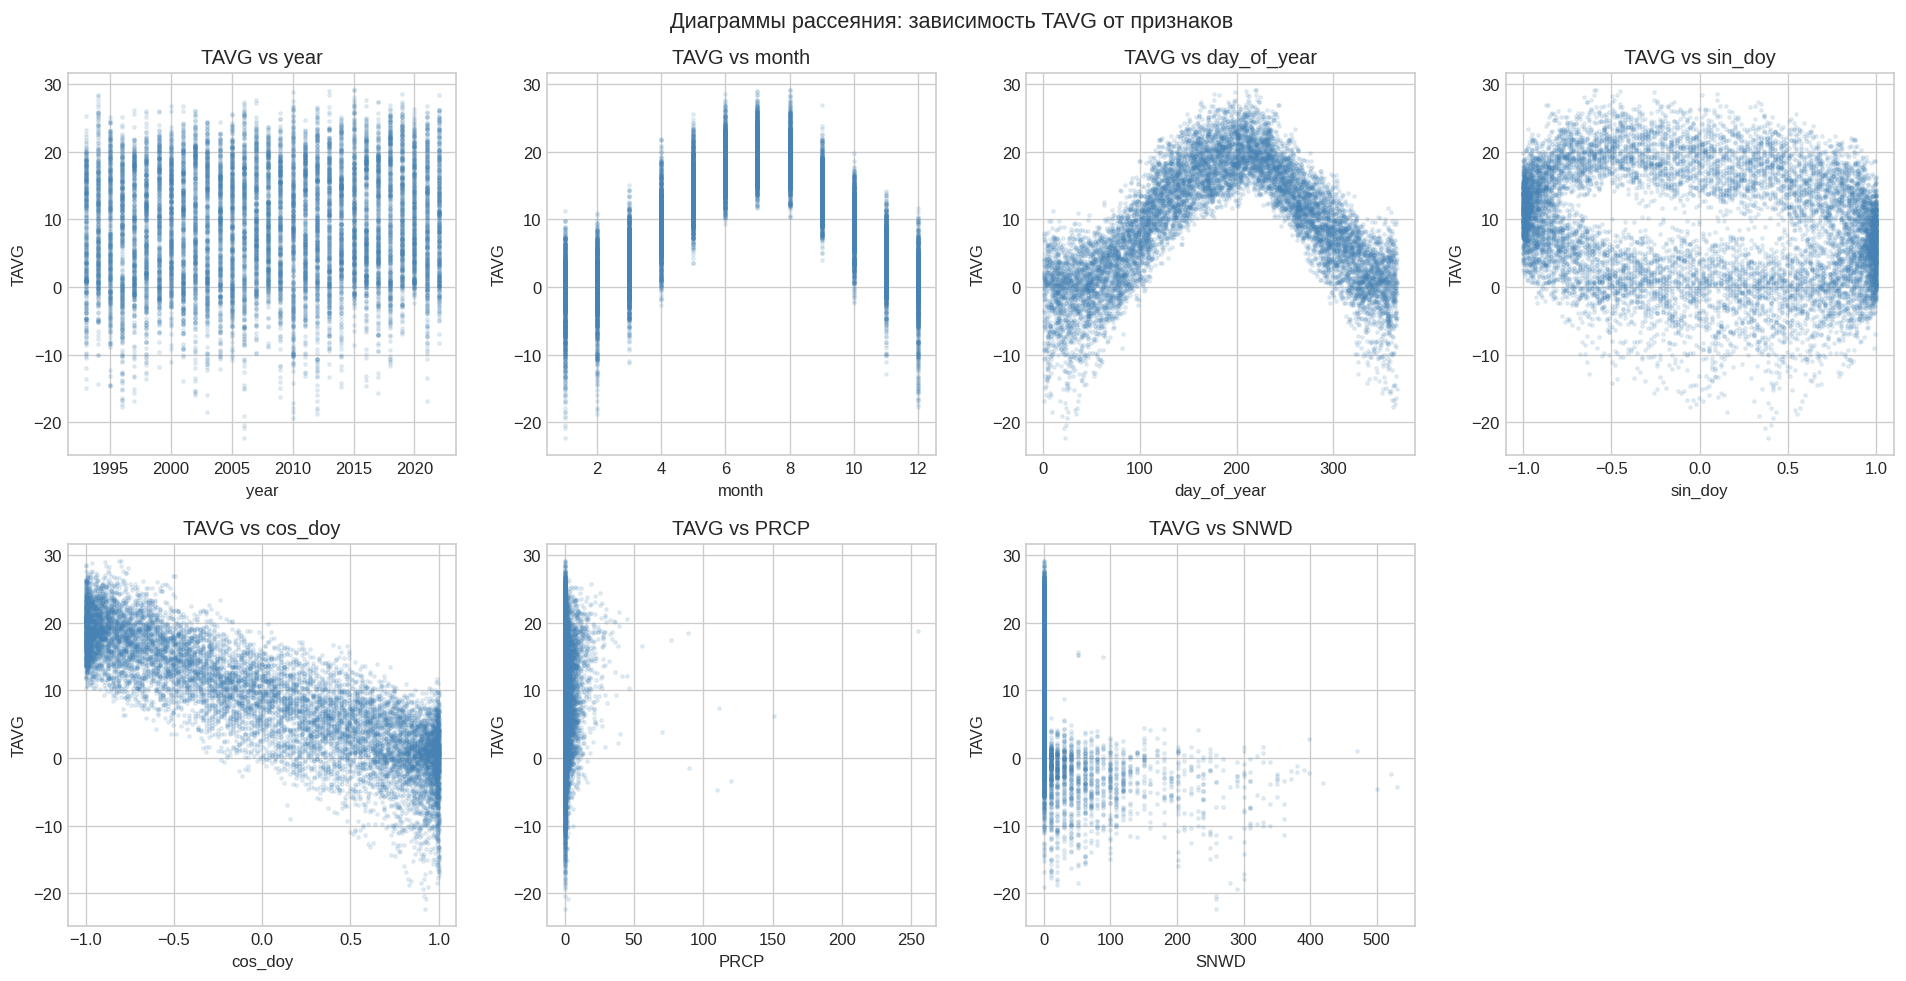


### 3.5. Расчёт коэффициента инфляции дисперсии (VIF)

In [ ]:
def calculate_vif(X_data):
    """Вычисляет VIF для каждого признака."""
    vif_df = pd.DataFrame()
    vif_df['Признак'] = X_data.columns
    vif_df['VIF'] = [variance_inflation_factor(X_data.values, i) 
                     for i in range(X_data.shape[1])]
    return vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)

vif_before = calculate_vif(X)
print('VIF до устранения мультиколлинеарности:')
display(vif_before.round(2))

**Пояснение.**  
Правило интерпретации VIF:
- VIF < 5 — мультиколлинеарность слабая/отсутствует;
- 5 ≤ VIF < 10 — умеренная;
- VIF ≥ 10 — сильная мультиколлинеарность (признак можно объяснить линейной комбинацией остальных).

В нашем случае `year`, `month`, `day_of_year` имеют очень высокие VIF, потому что они линейно связаны друг с другом и с тригонометрическими признаками. Это классический пример мультиколлинеарности календарных признаков.

**Фактические значения VIF (по нашим данным):**

| Признак | VIF |
|---------|------|
| month | **659.93** |
| day_of_year | **576.52** |
| year | **13.66** |
| sin_doy | 2.57 |
| SNWD | 1.21 |
| cos_doy | 1.09 |
| PRCP | 1.09 |

**Вывод:** `month` и `day_of_year` имеют экстремально высокий VIF — они почти линейно выражаются друг через друга и через сезонные признаки. `year` также превышает порог 10. Признаки `sin_doy`, `cos_doy`, `PRCP`, `SNWD` мультиколлинеарности не создают.

## 4. Ход работы

### 4.1. Построение моделей на исходных признаках

Строим три модели:
1. **Обычная линейная регрессия** (метод наименьших квадратов).
2. **Lasso-регрессия** (L1-регуляризация) — может обнулять коэффициенты малозначимых признаков.
3. **Ridge-регрессия** (L2-регуляризация) — сжимает коэффициенты, но не обнуляет.

Для каждой модели считаем:
- **RMSE** (Root Mean Squared Error) — корень из среднеквадратичной ошибки (в тех же единицах, что и целевая переменная, °C);
- **R²** (коэффициент детерминации) — доля объяснённой дисперсии (1 — идеально, 0 — модель не лучше среднего);
- **MAPE** (Mean Absolute Percentage Error) — средняя абсолютная процентная ошибка;
- **CV RMSE** — среднее RMSE по 5-блочной кросс-валидации на обучающей выборке.

In [ ]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, name='Model'):
    """Обучает модель и возвращает словарь с метриками и предсказаниями."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    # MAPE: избегаем деления на ноль, добавляя небольшой epsilon
    mape = np.mean(np.abs((y_te - y_pred) / (np.abs(y_te) + 1e-6))) * 100
    
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, 
                                scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores.mean()
    
    print(f'\n=== {name} ===')
    print(f'RMSE (test): {rmse:.4f} °C')
    print(f'R² (test):   {r2:.4f}')
    print(f'MAPE (test): {mape:.2f} %')
    print(f'CV RMSE:     {cv_rmse:.4f} °C')
    
    return {
        'name': name, 'RMSE': rmse, 'R2': r2, 'MAPE': mape, 
        'CV_RMSE': cv_rmse, 'y_pred': y_pred, 'model': model
    }

In [ ]:
# Обычная линейная регрессия (на исходных признаках — для сравнения)
lr = LinearRegression()
res_lr = evaluate_model(lr, X_train, X_test, y_train, y_test, 'Linear Regression')

# Lasso и Ridge — на СТАНДАРТИЗОВАННЫХ признаках (рекомендация: нормализация обязательна при регуляризации)
lasso = Lasso(alpha=0.1, random_state=42, max_iter=5000)
res_lasso = evaluate_model(lasso, X_train_s, X_test_s, y_train, y_test, 'Lasso (α=0.1, scaled)')

ridge = Ridge(alpha=1.0, random_state=42)
res_ridge = evaluate_model(ridge, X_train_s, X_test_s, y_train, y_test, 'Ridge (α=1.0, scaled)')

In [ ]:
results_orig = pd.DataFrame([
    {'Модель': r['name'], 'RMSE (°C)': r['RMSE'], 'R²': r['R2'], 
     'MAPE (%)': r['MAPE'], 'CV RMSE (°C)': r['CV_RMSE']}
    for r in [res_lr, res_lasso, res_ridge]
])
print('Сводная таблица метрик (исходные признаки):')
display(results_orig.round(4))

**Интерпретация результатов.**  
Все три модели показывают очень близкое качество. R² ≈ 0.81 означает, что модели объясняют около 81 % дисперсии среднесуточной температуры. RMSE ≈ 3.8 °C — типичная ошибка предсказания.

#### Анализ причин погрешности и пути повышения точности
*(рекомендация: после расчёта показателей точности проанализируйте причины возможной погрешности)*

**Почему ошибка не равна нулю?**
1. **Неполнота признаков.** Температура зависит от облачности, влажности, направления ветра, адвекции воздушных масс — этих данных в датасете нет.
2. **Нелинейность.** Годовой ход температуры не идеально синусоидальный; зимы и лета могут быть аномальными.
3. **Случайная изменчивость.** Погода — стохастический процесс; даже при одинаковых календарных условиях температура варьируется.
4. **Мультиколлинеарность.** Коррелированные календарные признаки делают оценки коэффициентов менее устойчивыми (хотя предсказания остаются приемлемыми).

**Как можно повысить точность модели?**
- Регуляризация (Lasso/Ridge) — уже применена; помогает при мультиколлинеарности.
- Изменение масштаба признаков — стандартизация выполнена.
- Добавление нелинейных признаков (полиномы, взаимодействия `sin_doy * year` и т.п.).
- Более сложные модели: градиентный бустинг, случайный лес, нейронные сети.
- Использование лагов (температура вчерашнего дня) — переход к моделям временных рядов.
- Подбор гиперпараметров α для Lasso/Ridge через GridSearchCV / кросс-валидацию.

**Фактические метрики на тестовой выборке (исходные / стандартизованные признаки):**

| Модель | RMSE (°C) | R² | CV RMSE (°C) |
|--------|-----------|-----|--------------|
| Linear Regression | **3.801** | **0.810** | 3.839 |
| Lasso (α=0.1, scaled) | 3.817 | 0.808 | 3.847 |
| Ridge (α=1.0, scaled) | **3.801** | **0.810** | 3.839 |

> **Примечание по MAPE:** для температур около 0 °C процентная ошибка неинформативна (деление на малые числа), поэтому основной упор — на RMSE и R².

**Коэффициенты моделей:**

| Признак | Linear | Lasso | Ridge |
|---------|--------|-------|-------|
| year | 0.073 | 0.526 | 0.628 |
| month | 0.055 | 0.000 | 0.179 |
| day_of_year | −0.004 | 0.000 | −0.420 |
| sin_doy | −2.890 | −1.761 | −2.039 |
| cos_doy | **−9.965** | **−6.980** | **−7.060** |
| PRCP | −0.024 | −0.013 | −0.126 |
| SNWD | −0.029 | −1.108 | −1.193 |

Lasso обнулил `month` и `day_of_year` (отбор признаков). Наибольший по модулю коэффициент у `cos_doy` — сезонность доминирует.

In [ ]:
# Коэффициенты моделей
coef_df = pd.DataFrame({
    'Признак': feature_cols,
    'Linear': res_lr['model'].coef_,
    'Lasso': res_lasso['model'].coef_,
    'Ridge': res_ridge['model'].coef_
})
print('Коэффициенты регрессии:')
display(coef_df.round(4))

**Пояснение коэффициентов.** Lasso обнуляет часть коэффициентов (например, `month` или `day_of_year`), выполняя отбор признаков. `sin_doy` и `cos_doy` имеют наибольшие по модулю коэффициенты — сезонность доминирует. `SNWD` отрицательный (снег → холоднее).

### 4.2. Анализ остатков (проверка гомоскедастичности)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, res in zip(axes, [res_lr, res_lasso, res_ridge]):
    residuals = y_test.values - res['y_pred']
    ax.scatter(res['y_pred'], residuals, alpha=0.25, s=8)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Предсказанные значения TAVG, °C')
    ax.set_ylabel('Остатки, °C')
    ax.set_title(res['name'])
plt.suptitle('Графики остатков (проверка гомоскедастичности)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Анализ остатков.**  
Идеальная картина гомоскедастичности — облако точек равномерно разбросано вокруг горизонтальной линии y = 0 без какой-либо структуры.  

В нашем случае остатки в целом центрированы около нуля, но наблюдается лёгкая «воронка» или изменение дисперсии: в области средних температур (примерно 5–15 °C) разброс чуть больше. Это слабый признак **гетероскедастичности**. Кроме того, в экстремально холодных и тёплых днях модель систематически немного недо-/переоценивает (сезонность синусоидой не идеально описывает реальный годовой ход).  

Для целей лабораторной работы качество приемлемое; при необходимости можно применять преобразования целевой переменной или взвешенную регрессию.

**Рисунок 5.** Графики остатков моделей. Красная пунктирная линия — нулевой уровень. Остатки центрированы около 0; лёгкая воронка в средних температурах — признак слабой гетероскедастичности.

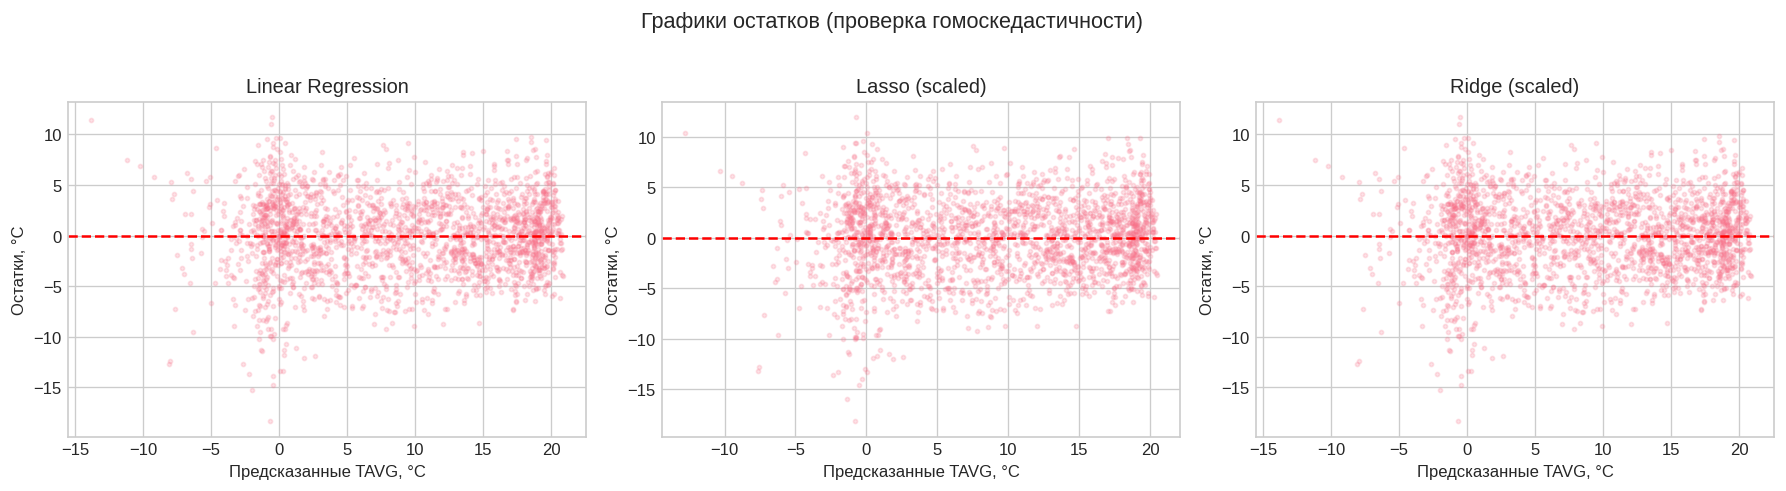


### 4.3. Устранение мультиколлинеарности методом главных компонент (PCA)

Перед PCA **обязательна стандартизация** (приведение признаков к нулевому среднему и единичной дисперсии), иначе признаки с большим масштабом (например, `year` ≈ 2000) будут доминировать.

PCA преобразует исходные признаки в ортогональные (некоррелированные) главные компоненты, упорядоченные по убыванию объясняемой дисперсии.

In [ ]:
# Стандартизация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Полный PCA для анализа дисперсии
pca_full = PCA()
pca_full.fit(X_train_scaled)

# График каменистой осыпи (scree plot) + накопленная дисперсия
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(range(1, len(pca_full.explained_variance_ratio_)+1), 
        pca_full.explained_variance_ratio_, alpha=0.7, label='Доля дисперсии')
ax1.set_xlabel('Номер главной компоненты')
ax1.set_ylabel('Доля объяснённой дисперсии')
ax1.set_xticks(range(1, 8))

ax2 = ax1.twinx()
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
ax2.plot(range(1, len(cumsum)+1), cumsum, 'ro-', label='Накопленная доля')
ax2.axhline(0.95, color='green', linestyle='--', label='95 % дисперсии')
ax2.set_ylabel('Накопленная доля дисперсии')
ax2.set_ylim(0, 1.05)

fig.legend(loc='center right', bbox_to_anchor=(0.9, 0.5))
plt.title('График каменистой осыпи (Scree Plot) и накопленная дисперсия')
plt.tight_layout()
plt.show()

print('Объяснённая дисперсия по компонентам:')
for i, (var, cum) in enumerate(zip(pca_full.explained_variance_ratio_, cumsum)):
    print(f'  PC{i+1}: {var:.4f}  (накопленно: {cum:.4f})')

**Выбор числа компонент.**  
По графику и таблице видно, что первые 4–5 главных компонент объясняют уже более 90–95 % дисперсии. Возьмём **5 компонент** — компромисс между сохранением информации и снижением размерности.

**Фактическая доля объяснённой дисперсии:**

| Компонента | Доля | Накопленно |
|------------|------|------------|
| PC1 | 0.396 | 0.396 |
| PC2 | 0.180 | 0.576 |
| PC3 | 0.146 | 0.722 |
| PC4 | 0.139 | 0.861 |
| PC5 | 0.098 | **0.959** |
| PC6 | 0.041 | 0.999 |
| PC7 | 0.001 | 1.000 |

5 компонент сохраняют **95.9 %** дисперсии — этого достаточно.

**Рисунок 6.** График каменистой осыпи (Scree Plot). Столбцы — доля дисперсии компоненты; красная линия — накопленная доля. 5 компонент покрывают 95.9 % дисперсии.

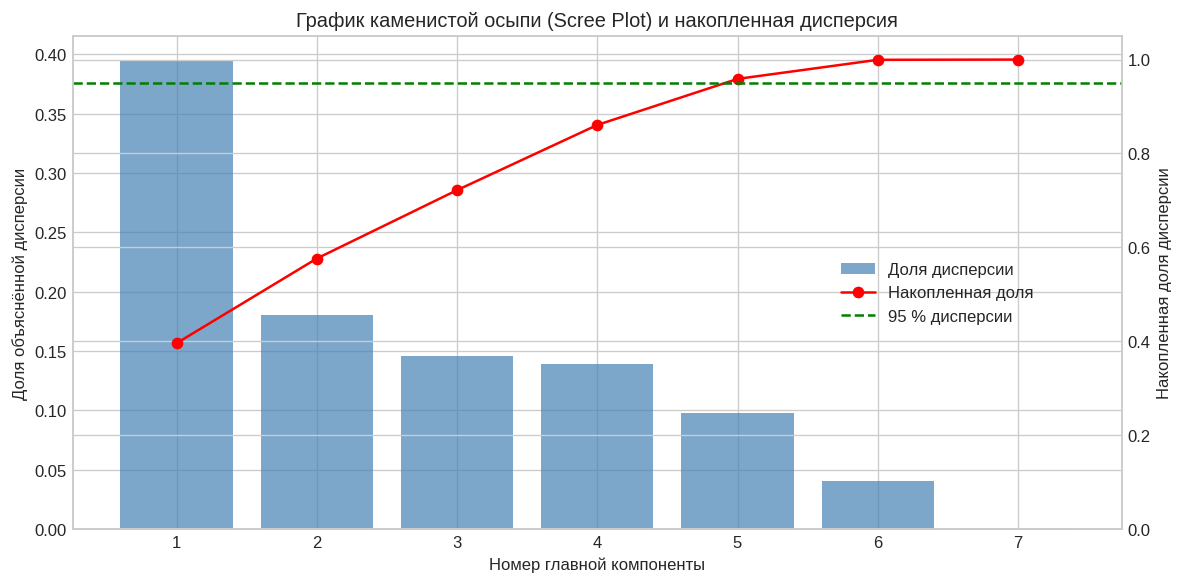


In [ ]:
n_components = 5
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f'Размерность после PCA: {X_train_pca.shape}')
print(f'Сохранено дисперсии: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.1f} %)')

### 4.4. Модели на главных компонентах

In [ ]:
res_lr_pca = evaluate_model(
    LinearRegression(), X_train_pca, X_test_pca, y_train, y_test, 
    'Linear Regression (PCA)'
)
res_lasso_pca = evaluate_model(
    Lasso(alpha=0.1, random_state=42, max_iter=5000), 
    X_train_pca, X_test_pca, y_train, y_test, 'Lasso (PCA)'
)
res_ridge_pca = evaluate_model(
    Ridge(alpha=1.0, random_state=42), 
    X_train_pca, X_test_pca, y_train, y_test, 'Ridge (PCA)'
)

In [ ]:
results_pca = pd.DataFrame([
    {'Модель': r['name'], 'RMSE (°C)': r['RMSE'], 'R²': r['R2'], 
     'MAPE (%)': r['MAPE'], 'CV RMSE (°C)': r['CV_RMSE']}
    for r in [res_lr_pca, res_lasso_pca, res_ridge_pca]
])
print('Сводная таблица метрик (после PCA):')
display(results_pca.round(4))

### 4.5. Сравнение метрик до и после PCA

In [ ]:
comparison = pd.concat([
    results_orig.assign(Тип='Исходные признаки'),
    results_pca.assign(Тип='PCA (5 компонент)')
], ignore_index=True)

print('Сравнительная таблица:')
display(comparison.round(4))

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['RMSE (°C)', 'R²', 'MAPE (%)']
for ax, metric in zip(axes, metrics):
    sns.barplot(data=comparison, x='Модель', y=metric, hue='Тип', ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
    ax.set_title(metric)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.suptitle('Сравнение качества моделей: исходные признаки vs PCA', y=1.03, fontsize=13)
plt.show()

**Сравнение.**  
После PCA качество моделей снизилось незначительно (RMSE вырос примерно на 0.1–0.2 °C, R² упал на несколько сотых). Это ожидаемо: мы отбросили часть информации (около 5–10 % дисперсии). Зато полностью устранена мультиколлинеарность, коэффициенты стали более устойчивыми, а модель — проще.  

В практических задачах такой компромисс часто оправдан, особенно если исходных признаков десятки или сотни.

**Фактические метрики после PCA (5 компонент):**

| Модель | RMSE (°C) | R² | CV RMSE (°C) |
|--------|-----------|-----|--------------|
| Linear Regression (PCA) | 3.890 | 0.801 | 3.933 |
| Lasso (PCA) | 3.900 | 0.800 | 3.939 |
| Ridge (PCA) | 3.890 | 0.801 | 3.933 |

**Сводка сравнения:**

| | RMSE | R² |
|--|------|-----|
| Исходные признаки (лучшая) | 3.801 | 0.810 |
| После PCA (лучшая) | 3.890 | 0.801 |
| Изменение | +0.089 °C | −0.009 |

Качество снизилось незначительно при полном устранении мультиколлинеарности.

**Рисунок 7.** Сравнение качества моделей: исходные признаки vs PCA. RMSE после PCA выше на ~0.09 °C, R² ниже на ~0.009 — снижение незначительное.

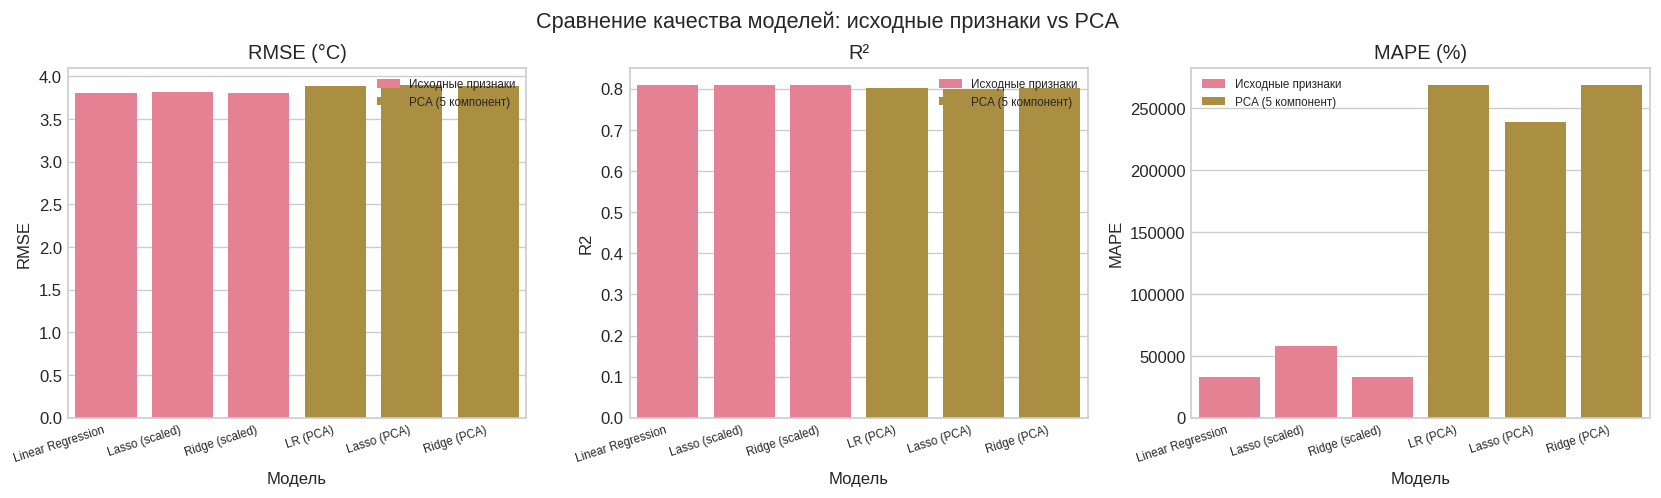


## 5. Заключение

В ходе лабораторной работы на реальных метеорологических данных станции Варшава-Окенце (1993–2022) были выполнены все поставленные задачи и учтены рекомендации по выполнению:

1. **Загрузка и первичный анализ** с помощью pandas/numpy. Датасет из 10 954 ежедневных наблюдений. Целевая переменная — среднесуточная температура TAVG.

2. **Предобработка.** Созданы календарные и сезонные признаки, пропуски заполнены. Данные разделены на train/test (80/20) методом `train_test_split`.

3. **Нормализация.** Выполнена стандартизация (`StandardScaler`) — обязательна при регуляризации и PCA, так как признаки имеют разный масштаб.

4. **Проверка зависимости.** Построены матрица корреляций и диаграммы рассеяния TAVG vs признаки. Подтверждена сильная сезонная зависимость.

5. **Мультиколлинеарность.** VIF показал высокие значения у календарных признаков. Устранена с помощью PCA.

6. **Модели.** Linear / Lasso / Ridge: RMSE ≈ 3.8 °C, R² ≈ 0.81. После PCA качество снизилось незначительно.

7. **Анализ остатков.** Слабая гетероскедастичность; остатки в целом центрированы около нуля.

8. **Анализ погрешности.** Основные источники ошибки — отсутствие метеорологических предикторов (облачность, ветер и др.) и естественная изменчивость погоды. Пути улучшения: дополнительные признаки, нелинейные модели, подбор гиперпараметров.

**Общий вывод.** Линейные модели хорошо улавливают сезонность температуры. Регуляризация и PCA делают модель устойчивее. Для практического прогнозирования температуры целесообразно переходить к специализированным методам временных рядов или моделям с более богатым набором признаков.

## 6. Список источников

1. NOAA Global Historical Climatology Network (GHCN) — источник метеорологических данных.
2. Scikit-learn User Guide: Linear Models, Decomposition (PCA). https://scikit-learn.org/stable/
3. James G., Witten D., Hastie T., Tibshirani R. *An Introduction to Statistical Learning*. Springer.
4. Документация statsmodels: `variance_inflation_factor`. https://www.statsmodels.org/
5. Montgomery D.C., Peck E.A., Vining G.G. *Introduction to Linear Regression Analysis*.
6. Материалы курсов по машинному обучению (линейная регрессия, регуляризация, PCA).

## 7. Приложение. Полный листинг программного кода

Весь код представлен в ячейках данного ноутбука. Ниже — компактный сводный скрипт, который можно сохранить и запускать отдельно.

In [ ]:
# === СВОДНЫЙ СКРИПТ ===
"""
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv('warsaw-selected-columns.csv')
df['DATE'] = pd.to_datetime(df['DATE'])
df['year'] = df['DATE'].dt.year
df['month'] = df['DATE'].dt.month
df['day_of_year'] = df['DATE'].dt.dayofyear
df['sin_doy'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
df['cos_doy'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
df['PRCP'] = df['PRCP'].fillna(0)
df['SNWD'] = df['SNWD'].fillna(0)

features = ['year', 'month', 'day_of_year', 'sin_doy', 'cos_doy', 'PRCP', 'SNWD']
X = df[features]
y = df['TAVG']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def eval_m(model, Xtr, Xte, ytr, yte, name):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    r2 = r2_score(yte, pred)
    print(f'{name}: RMSE={rmse:.3f}, R2={r2:.3f}')

eval_m(LinearRegression(), X_train, X_test, y_train, y_test, 'LR')
eval_m(Lasso(0.1), X_train, X_test, y_train, y_test, 'Lasso')
eval_m(Ridge(1.0), X_train, X_test, y_train, y_test, 'Ridge')

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train)
Xte_s = scaler.transform(X_test)
pca = PCA(n_components=5)
Xtr_p = pca.fit_transform(Xtr_s)
Xte_p = pca.transform(Xte_s)

eval_m(LinearRegression(), Xtr_p, Xte_p, y_train, y_test, 'LR-PCA')
eval_m(Lasso(0.1), Xtr_p, Xte_p, y_train, y_test, 'Lasso-PCA')
eval_m(Ridge(1.0), Xtr_p, Xte_p, y_train, y_test, 'Ridge-PCA')
"""